## Load and Prepare the Diabetes Dataset

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# Load the diabetes dataset
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (353, 10)
Testing data shape: (89, 10)


## Perform Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

# Create a Linear Regression model
linear_reg_model = LinearRegression()

# Train the model using the training data
linear_reg_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Evaluate the Model

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test data
y_pred = linear_reg_model.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 2900.19
R-squared (R2): 0.45


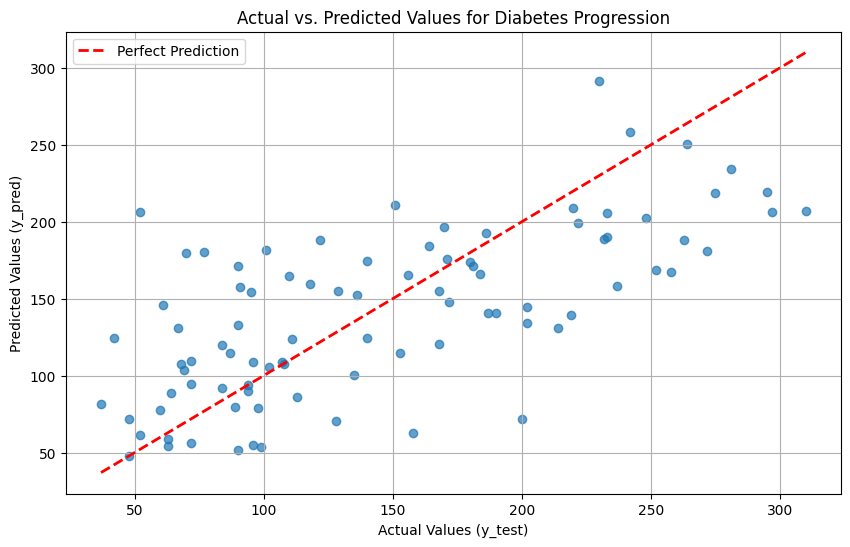

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Actual vs. Predicted Values for Diabetes Progression')
plt.grid(True)
plt.legend()
plt.show()

The Mean Squared Error (MSE) and R-squared (R2) metrics indicate the performance of the linear regression model on the diabetes dataset. A lower MSE suggests a better fit, and an R2 closer to 1 indicates that a larger proportion of the variance in the dependent variable is predictable from the independent variables.

## K-Means Clustering

In [ ]:
from sklearn.cluster import KMeans

# For demonstration, let's choose 3 clusters. The optimal number of clusters can be determined using methods like the elbow method.
k_means_model = KMeans(n_clusters=3, random_state=42, n_init=10) # n_init is set to 'auto' or an integer in newer versions of sklearn
k_means_model.fit(X) # X is the original feature data

# Get cluster labels for each data point
cluster_labels = k_means_model.labels_

print(f"K-Means clustering performed with {k_means_model.n_clusters} clusters.")
print(f"First 10 cluster labels: {cluster_labels[:10]}")

K-Means clustering performed with 3 clusters.
First 10 cluster labels: [1 2 1 1 2 2 2 0 1 1]


## Principal Component Analysis (PCA) for Visualization

In [ ]:
from sklearn.decomposition import PCA

# Reduce the data to 2 principal components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(f"Original data shape: {X.shape}")
print(f"PCA-transformed data shape: {X_pca.shape}")
print(f"Explained variance ratio by first 2 components: {pca.explained_variance_ratio_.sum():.2f}")

Original data shape: (442, 10)
PCA-transformed data shape: (442, 2)
Explained variance ratio by first 2 components: 0.55


## K-Means Clusters vs. PCA Visualization

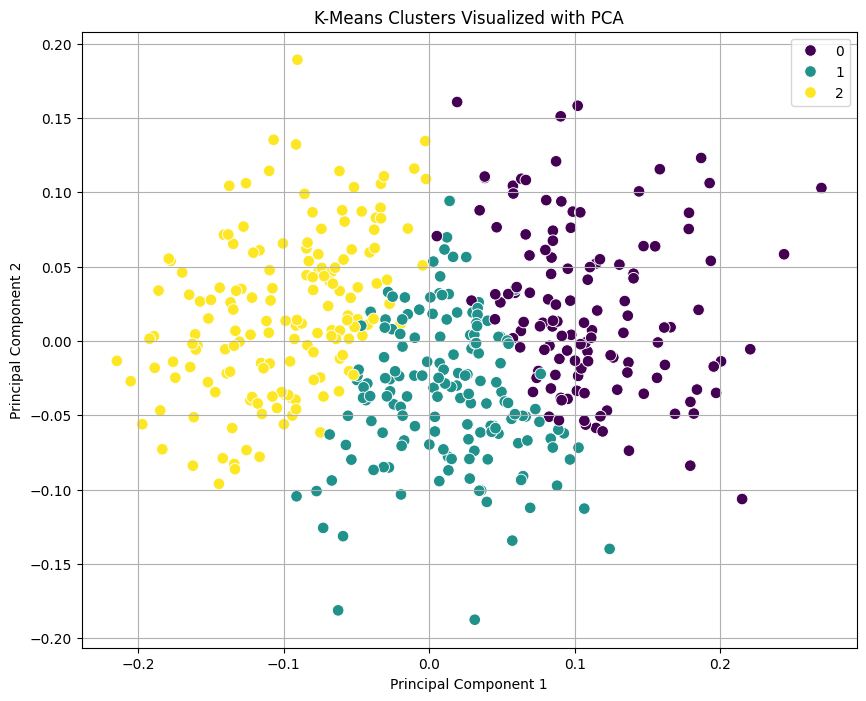

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='viridis', legend='full', s=70)
plt.title('K-Means Clusters Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## Actual Target Variable vs. PCA Visualization

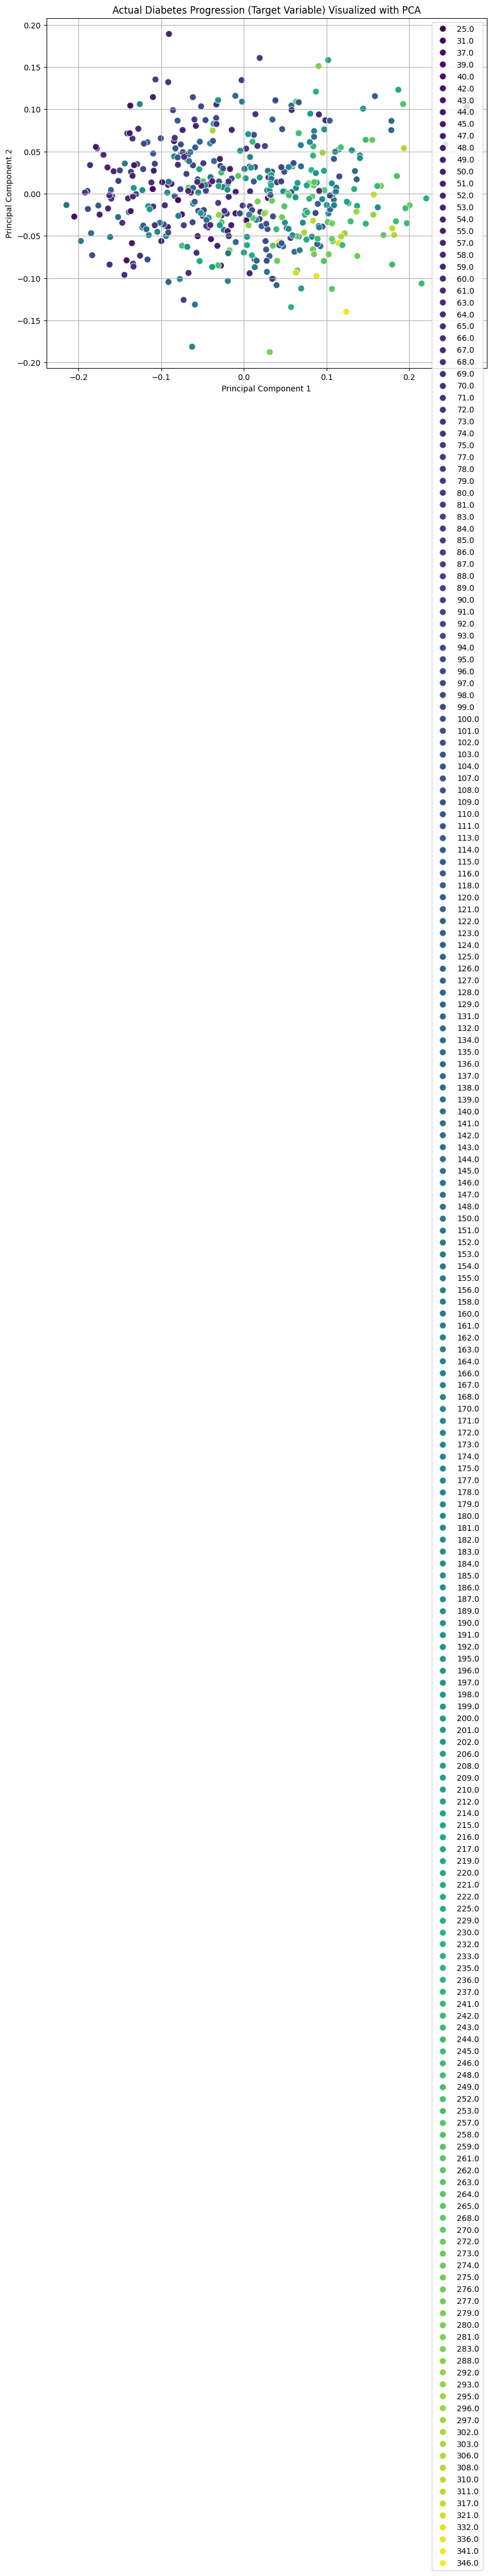

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', legend='full', s=70)
plt.title('Actual Diabetes Progression (Target Variable) Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## Correlation Analysis: PCA Components vs. Target Variable

In [ ]:
import numpy as np

# Calculate correlation between PCA Component 1 and y
correlation_pca1_y = np.corrcoef(X_pca[:, 0], y)[0, 1]

# Calculate correlation between PCA Component 2 and y
correlation_pca2_y = np.corrcoef(X_pca[:, 1], y)[0, 1]

print(f"Correlation between PCA Component 1 and Target Variable (y): {correlation_pca1_y:.2f}")
print(f"Correlation between PCA Component 2 and Target Variable (y): {correlation_pca2_y:.2f}")

Correlation between PCA Component 1 and Target Variable (y): 0.56
Correlation between PCA Component 2 and Target Variable (y): -0.19


By comparing this plot with the 'K-Means Clusters Visualized with PCA' plot, you can visually assess how well the clusters found by K-Means align with the actual progression levels of diabetes. If there's a strong correspondence, you would expect to see similar patterns of color gradients in both plots, suggesting that the clusters might be picking up on natural groupings related to disease progression.

## K-Means Inertia Comparison (with and without PCA)

In [ ]:
# Perform K-Means clustering on PCA-transformed data
# Using the same number of clusters (3) as before
k_means_model_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
k_means_model_pca.fit(X_pca)

# Get inertia for K-Means on original data (from previous run)
inertia_original = k_means_model.inertia_

# Get inertia for K-Means on PCA-transformed data
inertia_pca = k_means_model_pca.inertia_

print(f"K-Means Inertia (Original Data): {inertia_original:.2f}")
print(f"K-Means Inertia (PCA-Transformed Data): {inertia_pca:.2f}")

K-Means Inertia (Original Data): 6.51
K-Means Inertia (PCA-Transformed Data): 2.08


## Silhouette Score Comparison (with and without PCA)

In [ ]:
from sklearn.metrics import silhouette_score

# Get cluster labels for K-Means on PCA-transformed data
cluster_labels_pca = k_means_model_pca.labels_

# Calculate Silhouette Score for K-Means on original data
silhouette_original = silhouette_score(X, cluster_labels)

# Calculate Silhouette Score for K-Means on PCA-transformed data
silhouette_pca = silhouette_score(X_pca, cluster_labels_pca)

print(f"Silhouette Score (Original Data): {silhouette_original:.2f}")
print(f"Silhouette Score (PCA-Transformed Data): {silhouette_pca:.2f}")

Silhouette Score (Original Data): 0.15
Silhouette Score (PCA-Transformed Data): 0.33


## 3D Visualization of K-Means Clusters with PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Reduce the data to 3 principal components for 3D visualization
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)

print(f"Original data shape: {X.shape}")
print(f"PCA-transformed data shape (3D): {X_pca_3d.shape}")
print(f"Explained variance ratio by first 3 components: {pca_3d.explained_variance_ratio_.sum():.2f}")


Original data shape: (442, 10)
PCA-transformed data shape (3D): (442, 3)
Explained variance ratio by first 3 components: 0.67


In [ ]:
# Perform K-Means clustering on the 3D PCA-transformed data
k_means_model_pca_3d = KMeans(n_clusters=3, random_state=42, n_init=10)
k_means_model_pca_3d.fit(X_pca_3d)
cluster_labels_pca_3d = k_means_model_pca_3d.labels_

print(f"K-Means clustering performed with {k_means_model_pca_3d.n_clusters} clusters on 3D PCA data.")

K-Means clustering performed with 3 clusters on 3D PCA data.


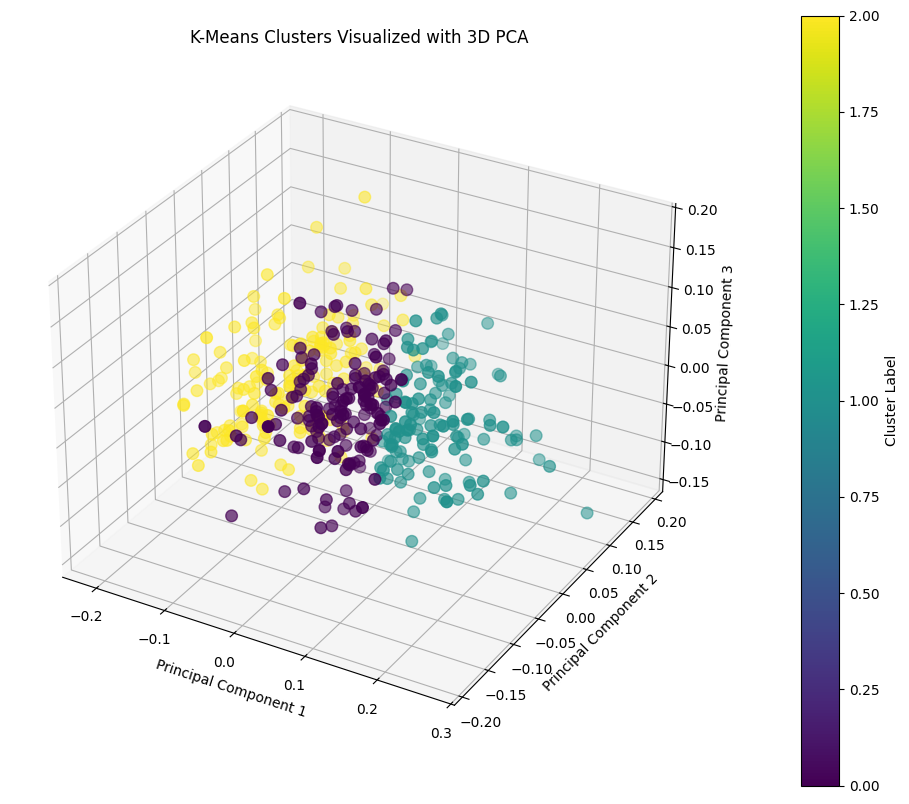

In [ ]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create the 3D scatter plot
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                     c=cluster_labels_pca_3d, cmap='viridis', s=70)

ax.set_title('K-Means Clusters Visualized with 3D PCA')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# Add a color bar
cbar = fig.colorbar(scatter, pad=0.1)
cbar.set_label('Cluster Label')

plt.grid(True)
plt.show()

## Cross-Validation for Linear Regression Model

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
import numpy as np

# Initialize a Linear Regression model (re-using the existing model or creating a new one)
# For cross-validation, it's often good practice to initialize a fresh model instance
cv_linear_reg_model = LinearRegression()

# Define the cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and calculate the negative mean squared error
mse_scores = -cross_val_score(cv_linear_reg_model, X, y, cv=kf, scoring='neg_mean_squared_error')

# Perform cross-validation and calculate the R-squared score
r2_scores = cross_val_score(cv_linear_reg_model, X, y, cv=kf, scoring='r2')

print(f"Mean Squared Error (MSE) for each fold: {mse_scores.round(2)}")
print(f"Average MSE from 5-fold cross-validation: {np.mean(mse_scores):.2f} (+/- {np.std(mse_scores):.2f})")
print()
print(f"R-squared (R2) for each fold: {r2_scores.round(2)}")
print(f"Average R2 from 5-fold cross-validation: {np.mean(r2_scores):.2f} (+/- {np.std(r2_scores):.2f})")

Mean Squared Error (MSE) for each fold: [2900.19 2662.64 3312.31 2797.88 3403.89]
Average MSE from 5-fold cross-validation: 3015.38 (+/- 291.24)

R-squared (R2) for each fold: [0.45 0.57 0.39 0.58 0.39]
Average R2 from 5-fold cross-validation: 0.48 (+/- 0.08)


## Compare Linear Regression Performance with and without PCA

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# --- Linear Regression with 2-component PCA data ---
# Split the PCA-transformed data into training and testing sets
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

linear_reg_model_pca = LinearRegression()
linear_reg_model_pca.fit(X_pca_train, y_pca_train)
y_pca_pred = linear_reg_model_pca.predict(X_pca_test)

mse_pca = mean_squared_error(y_pca_test, y_pca_pred)
r2_pca = r2_score(y_pca_test, y_pca_pred)

print(f"--- Linear Regression with 2-component PCA ---")
print(f"Mean Squared Error (MSE) on PCA data: {mse_pca:.2f}")
print(f"R-squared (R2) on PCA data: {r2_pca:.2f}")
print()

# --- Linear Regression with 3-component PCA data ---
# Split the 3D PCA-transformed data into training and testing sets
X_pca_3d_train, X_pca_3d_test, y_pca_3d_train, y_pca_3d_test = train_test_split(X_pca_3d, y, test_size=0.2, random_state=42)

linear_reg_model_pca_3d = LinearRegression()
linear_reg_model_pca_3d.fit(X_pca_3d_train, y_pca_3d_train)
y_pca_3d_pred = linear_reg_model_pca_3d.predict(X_pca_3d_test)

mse_pca_3d = mean_squared_error(y_pca_3d_test, y_pca_3d_pred)
r2_pca_3d = r2_score(y_pca_3d_test, y_pca_3d_pred)

print(f"--- Linear Regression with 3-component PCA ---")
print(f"Mean Squared Error (MSE) on 3D PCA data: {mse_pca_3d:.2f}")
print(f"R-squared (R2) on 3D PCA data: {r2_pca_3d:.2f}")
print()

# --- Original Linear Regression Results for Comparison ---
print(f"--- Original Linear Regression (Full Data) ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

--- Linear Regression with 2-component PCA ---
Mean Squared Error (MSE) on PCA data: 3534.24
R-squared (R2) on PCA data: 0.33

--- Linear Regression with 3-component PCA ---
Mean Squared Error (MSE) on 3D PCA data: 3677.67
R-squared (R2) on 3D PCA data: 0.31

--- Original Linear Regression (Full Data) ---
Mean Squared Error (MSE): 2900.19
R-squared (R2): 0.45


## Residuals Plot for Linear Regression Model

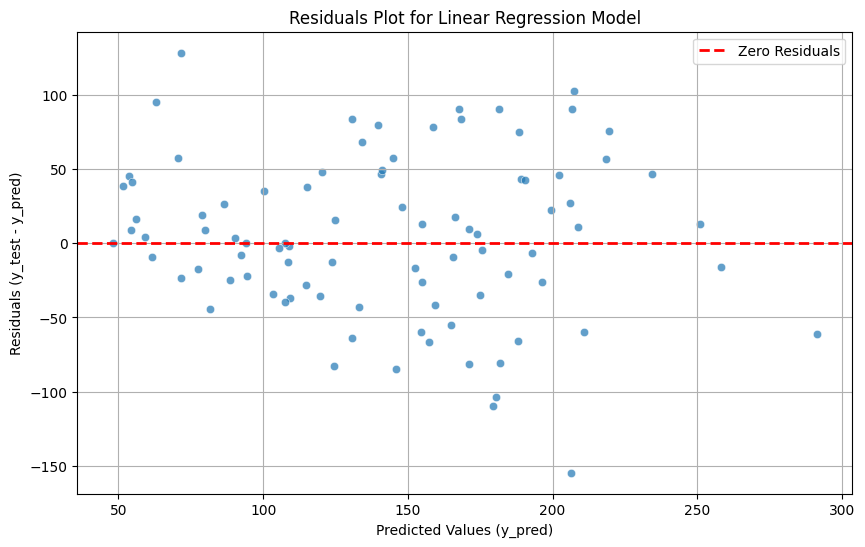

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Residuals')
plt.xlabel('Predicted Values (y_pred)')
plt.ylabel('Residuals (y_test - y_pred)')
plt.title('Residuals Plot for Linear Regression Model')
plt.grid(True)
plt.legend()
plt.show()

## Top 2 Features vs. Target Variable

Top 2 Features and their correlations with the Target Variable:


,feature,correlation,abs_correlation
2,bmi,0.586450,0.586450
8,s5,0.565883,0.565883


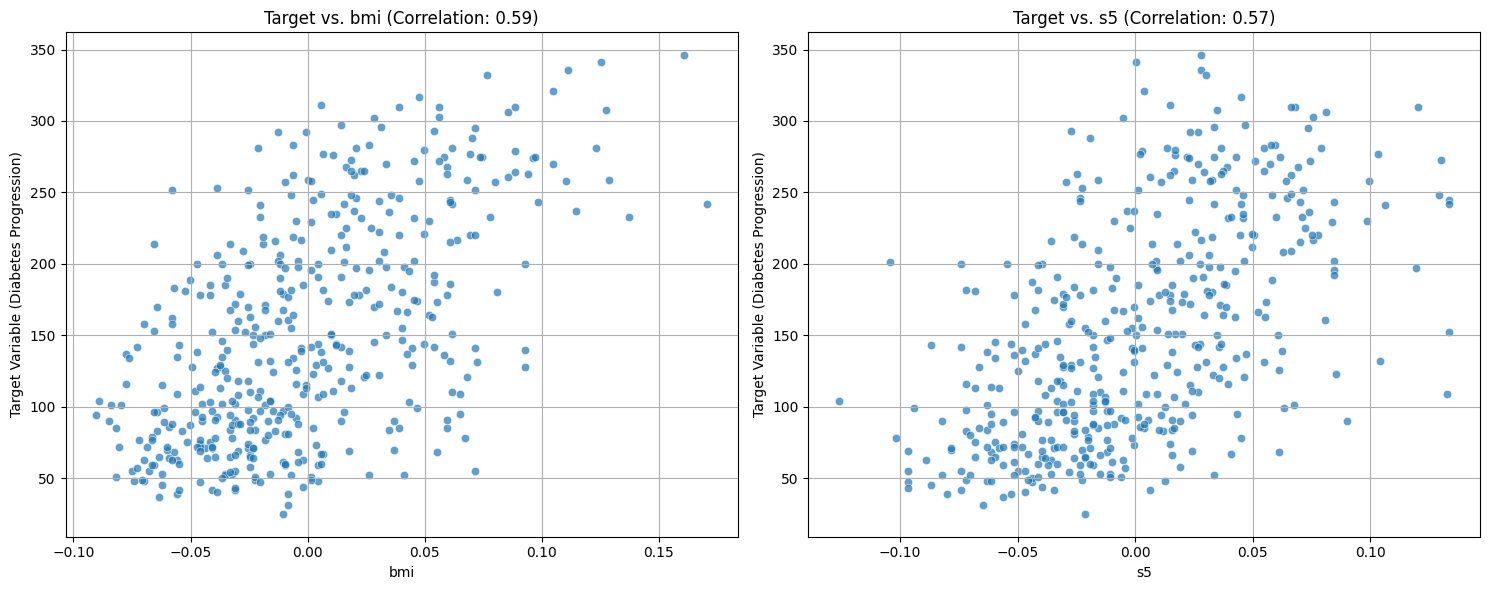

In [ ]:
from sklearn.datasets import load_diabetes
import pandas as pd

# Load the diabetes dataset again to get feature names
diabetes_data = load_diabetes()
feature_names = diabetes_data.feature_names

# Calculate correlation between each feature and the target variable
# X is already scaled, so direct correlation can be computed
correlations = [np.corrcoef(X[:, i], y)[0, 1] for i in range(X.shape[1])]

# Create a DataFrame to easily sort and access feature names
correlation_df = pd.DataFrame({'feature': feature_names, 'correlation': correlations})
correlation_df['abs_correlation'] = correlation_df['correlation'].abs()

# Get the top 2 features based on absolute correlation
top_2_features = correlation_df.sort_values(by='abs_correlation', ascending=False).head(2)

print("Top 2 Features and their correlations with the Target Variable:")
display(top_2_features)

# Plotting the relationship for the top 2 features
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot for the first top feature
top_feature_idx_1 = correlation_df[correlation_df['feature'] == top_2_features.iloc[0]['feature']].index[0]
sns.scatterplot(x=X[:, top_feature_idx_1], y=y, ax=axes[0], alpha=0.7)
axes[0].set_title(f'Target vs. {top_2_features.iloc[0]['feature']} (Correlation: {top_2_features.iloc[0]['correlation']:.2f})')
axes[0].set_xlabel(top_2_features.iloc[0]['feature'])
axes[0].set_ylabel('Target Variable (Diabetes Progression)')
axes[0].grid(True)

# Plot for the second top feature
top_feature_idx_2 = correlation_df[correlation_df['feature'] == top_2_features.iloc[1]['feature']].index[0]
sns.scatterplot(x=X[:, top_feature_idx_2], y=y, ax=axes[1], alpha=0.7)
axes[1].set_title(f'Target vs. {top_2_features.iloc[1]['feature']} (Correlation: {top_2_features.iloc[1]['correlation']:.2f})')
axes[1].set_xlabel(top_2_features.iloc[1]['feature'])
axes[1].set_ylabel('Target Variable (Diabetes Progression)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Compare Model Performance After Removing Outliers

In [ ]:
from scipy.stats import iqr

# Calculate IQR for the target variable (y)
Q1 = np.percentile(y, 25)
Q3 = np.percentile(y, 75)
IQR_value = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR_value
upper_bound = Q3 + 1.5 * IQR_value

# Identify outliers in y
outlier_indices = np.where((y < lower_bound) | (y > upper_bound))

# Create a new dataset with outliers removed
X_cleaned = np.delete(X, outlier_indices, axis=0)
y_cleaned = np.delete(y, outlier_indices, axis=0)

print(f"Original dataset size: {X.shape[0]}")
print(f"Number of outliers removed: {len(outlier_indices[0])}")
print(f"Cleaned dataset size: {X_cleaned.shape[0]}")


Original dataset size: 442
Number of outliers removed: 0
Cleaned dataset size: 442


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split the cleaned data into training and testing sets
X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

# Create and train a Linear Regression model on the cleaned data
linear_reg_model_cleaned = LinearRegression()
linear_reg_model_cleaned.fit(X_train_cleaned, y_train_cleaned)

# Make predictions on the cleaned test data
y_pred_cleaned = linear_reg_model_cleaned.predict(X_test_cleaned)

# Calculate Mean Squared Error and R-squared for the cleaned model
mse_cleaned = mean_squared_error(y_test_cleaned, y_pred_cleaned)
r2_cleaned = r2_score(y_test_cleaned, y_pred_cleaned)

print(f"--- Linear Regression Performance (Outliers Removed) ---")
print(f"Mean Squared Error (MSE) on cleaned data: {mse_cleaned:.2f}")
print(f"R-squared (R2) on cleaned data: {r2_cleaned:.2f}")
print()

print(f"--- Original Linear Regression Performance (for comparison) ---")
print(f"Mean Squared Error (MSE) on original data: {mse:.2f}")
print(f"R-squared (R2) on original data: {r2:.2f}")

--- Linear Regression Performance (Outliers Removed) ---
Mean Squared Error (MSE) on cleaned data: 2900.19
R-squared (R2) on cleaned data: 0.45

--- Original Linear Regression Performance (for comparison) ---
Mean Squared Error (MSE) on original data: 2900.19
R-squared (R2) on original data: 0.45
